In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Special cases
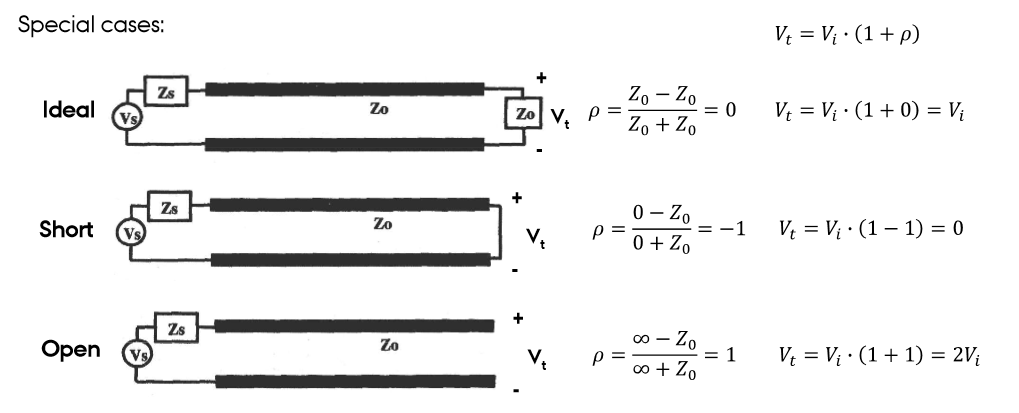

# Circuit
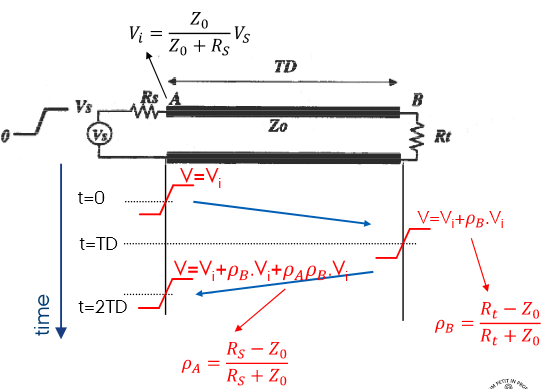
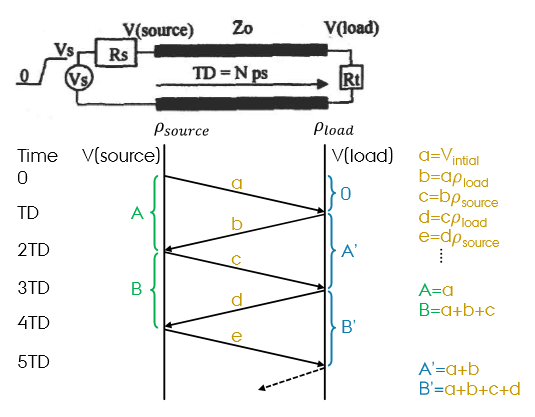

In [2]:
# Constants
Zs = 75 # ohms
Z0 = 50 # ohms
Vs = 2  # V
Zload = np.inf # load resistance ohm

# reflection coefficient
load_is_open = True
load_is_short = False

if load_is_open:
    rho_load = 1
elif load_is_short:
    rho_load = 0
else:
    rho_load = (Zload - Z0)/(Zload + Z0)

rho_source = (Zs - Z0)/(Zs + Z0)

print(f'rho_source = {rho_source}')
print(f'rho_load = {rho_load}')

rho_source = 0.2
rho_load = 1


In [3]:
# initial voltage
Vi = Vs * Z0/(Z0 + Zs)

print(f'Vi = {Vi}')

Vi = 0.8


In [15]:
print("\nDoing calculations...\n")

deltas = []        # a, b, c, d ...
source_voltages = [] # A, B, C, D ...
load_voltages = [] # A', B', C', D' ...

iterations = 10

for i in range(iterations):

    if i > 0 and i % 2 == 0:
        # even iteration. We're on the source side.
        deltas.append(deltas[i-1]*rho_source)
    elif i > 0 and i % 2 == 1:
        # uneven iteration. We're on the load side.
        deltas.append(deltas[i-1]*rho_load)
    elif i == 0:
        # a = V_i
        deltas.append(Vi)

for i in range(len(deltas)):
    if i % 2 == 0:
        source_voltages.append(sum(deltas[:i+1]))
    else:
        load_voltages.append(sum(deltas[:i+1]))

print('deltas', deltas)
print('source voltages', source_voltages)
print('load voltages', load_voltages)


Doing calculations...

deltas [0.8, 0.8, 0.16000000000000003, 0.16000000000000003, 0.03200000000000001, 0.03200000000000001, 0.006400000000000002, 0.006400000000000002, 0.0012800000000000005, 0.0012800000000000005]
source voltages [0.8, 1.7600000000000002, 1.9520000000000002, 1.9904000000000002, 1.99808]
load voltages [1.6, 1.9200000000000002, 1.9840000000000002, 1.9968000000000001, 1.9993600000000002]


# Automatic Plots


Making plots...
[0, 2, 4, 6, 8]
[0, 1, 3, 5, 7, 9]


C:\Users\david\AppData\Local\Temp\ipykernel_13436\2312824702.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


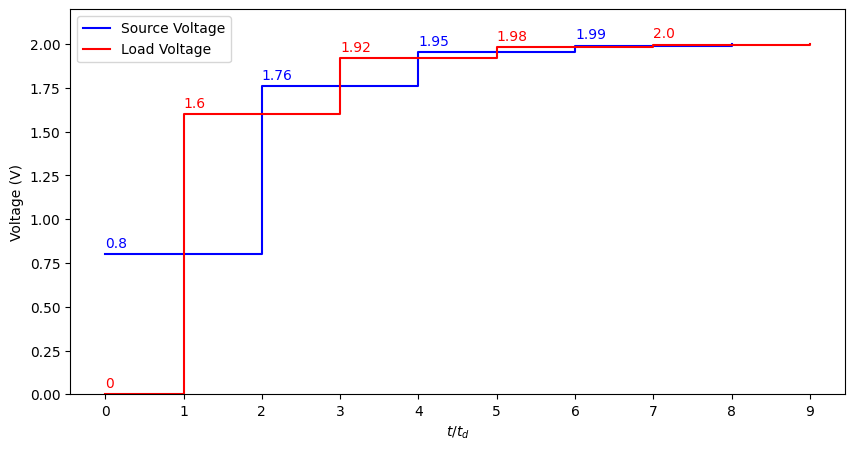

In [14]:
print('\nMaking plots...')
fig, ax = plt.subplots(figsize=(10,5))

load_voltages_w_initial = [0] + load_voltages

len_source_plot = len(source_voltages)
len_load_plot = len(load_voltages_w_initial)

source_plot_indices = [i for i in range(0, len_source_plot*2, 2)]
load_plot_indices = [0] + [i for i in range(1, len_load_plot*2 - 2, 2)]
print(source_plot_indices)
print(load_plot_indices)

ax.step(source_plot_indices, source_voltages, where='post', color='blue')
ax.step(load_plot_indices, load_voltages_w_initial, where='post', color='red')
ax.set_xticks([i for i in range(0,load_plot_indices[-1]+1)])
ax.set_ylim(0, max(source_voltages)*1.1)
ax.set_xlabel('$t/t_d$')
ax.set_ylabel('Voltage (V)')
ax.legend(['Source Voltage', 'Load Voltage'])

# Annotate source voltages
for x, y in zip(source_plot_indices[:-1], source_voltages[:-1]):
    ax.annotate(f'{round(y, 2)}', xy=(x, y), xytext=(0, 5), textcoords='offset points', ha='left', color='blue')

# Annotate load voltages
for x, y in zip(load_plot_indices[:-1], load_voltages_w_initial[:-1]):
    ax.annotate(f'{round(y, 2)}', xy=(x, y), xytext=(0, 5), textcoords='offset points', ha='left', color='red')

fig.show()